In [23]:
import numpy as np
import pandas as pd 

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import wilcoxon
from scipy.stats import spearmanr

import umap

import os
import json
import random

from tqdm import tqdm

/home/arbiter/projects/Survey-invariant-generalization/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
reg_mu    = np.load("/home/arbiter/projects/Survey-invariant-generalization/src/models/reg_mu.npy")
reg_sigma = np.load("/home/arbiter/projects/Survey-invariant-generalization/src/models/reg_sigma.npy")

experiments_dir = "/home/arbiter/projects/Survey-invariant-generalization/experiments/experiments_data"

seeds = [1, 7, 42, 85, 123, 156, 234, 301, 412, 500, 617, 724, 836, 901, 999, 1042]

## H1

Comparing reconstruction of spectra across experiment seeds

In [3]:
sdss_recon_maes = []
lamost_recon_maes = []

failed_seeds = []

for seed in seeds:

    seed_dir = os.path.join(experiments_dir, f"experiment_{seed}")
    
    try:
        sdss_flux = np.load(os.path.join(seed_dir, "sdss_flux.npy"))
        sdss_recon = np.load(os.path.join(seed_dir, "sdss_x_hat.npy"))

        lamost_flux = np.load(os.path.join(seed_dir, "lamost_flux.npy"))
        lamost_recon = np.load(os.path.join(seed_dir, "lamost_x_hat.npy"))

        # computing MAE
        sdss_mae = np.mean(np.abs(sdss_flux - sdss_recon))
        lamost_mae = np.mean(np.abs(lamost_flux - lamost_recon))

        sdss_recon_maes.append(sdss_mae)
        lamost_recon_maes.append(lamost_mae)

        print(f"Seed {seed:>4} | SDSS MAE: {sdss_mae:.4f} | LAMOST MAE: {lamost_mae:.4f}")

    except FileNotFoundError as e:
        print(f"Seed {seed} — missing files: {e}")
        failed_seeds.append(seed)


sdss_recon_maes   = np.array(sdss_recon_maes)
lamost_recon_maes = np.array(lamost_recon_maes)

# summary statistics

print("\n" + "=" * 50)
print("RECONSTRUCTION MAE ACROSS SEEDS")
print("=" * 50)
print(f"SDSS   MAE: {sdss_recon_maes.mean():.4f} ± {sdss_recon_maes.std():.4f}")
print(f"LAMOST MAE: {lamost_recon_maes.mean():.4f} ± {lamost_recon_maes.std():.4f}")
print(f"Ratio LAMOST/SDSS: {(lamost_recon_maes/sdss_recon_maes).mean():.4f}")

if failed_seeds:
    print(f"\nFailed seeds: {failed_seeds}")

# save results
results = {
    "seeds"             : seeds,
    "sdss_recon_maes"   : sdss_recon_maes.tolist(),
    "lamost_recon_maes" : lamost_recon_maes.tolist(),
    "sdss_mean"         : float(sdss_recon_maes.mean()),
    "sdss_std"          : float(sdss_recon_maes.std()),
    "lamost_mean"       : float(lamost_recon_maes.mean()),
    "lamost_std"        : float(lamost_recon_maes.std()),
    "ratio_mean"        : float((lamost_recon_maes/sdss_recon_maes).mean())
}

with open(os.path.join(experiments_dir, "recon_mae_results.json"), "w") as f:
    json.dump(results, f, indent=2)

print("\nSaved to recon_mae_results.json")

Seed    1 | SDSS MAE: 0.1997 | LAMOST MAE: 0.1692
Seed    7 | SDSS MAE: 0.1977 | LAMOST MAE: 0.1651
Seed   42 | SDSS MAE: 0.1914 | LAMOST MAE: 0.1618
Seed   85 | SDSS MAE: 0.1902 | LAMOST MAE: 0.1611
Seed  123 | SDSS MAE: 0.1860 | LAMOST MAE: 0.1568
Seed  156 | SDSS MAE: 0.1940 | LAMOST MAE: 0.1623
Seed  234 | SDSS MAE: 0.1903 | LAMOST MAE: 0.1633
Seed  301 | SDSS MAE: 0.1906 | LAMOST MAE: 0.1629
Seed  412 | SDSS MAE: 0.1953 | LAMOST MAE: 0.1640
Seed  500 | SDSS MAE: 0.1939 | LAMOST MAE: 0.1665
Seed  617 | SDSS MAE: 0.1938 | LAMOST MAE: 0.1578
Seed  724 | SDSS MAE: 0.2003 | LAMOST MAE: 0.1633
Seed  836 | SDSS MAE: 0.1967 | LAMOST MAE: 0.1646
Seed  901 | SDSS MAE: 0.1893 | LAMOST MAE: 0.1618
Seed  999 | SDSS MAE: 0.1880 | LAMOST MAE: 0.1587
Seed 1042 | SDSS MAE: 0.1962 | LAMOST MAE: 0.1672

RECONSTRUCTION MAE ACROSS SEEDS
SDSS   MAE: 0.1933 ± 0.0040
LAMOST MAE: 0.1629 ± 0.0032
Ratio LAMOST/SDSS: 0.8427

Saved to recon_mae_results.json


#### Wilcoxon Ranked Test on reconstruction

In [4]:
stat, p = wilcoxon(
    lamost_recon_maes,
    sdss_recon_maes,
    alternative="greater"   # H1: LAMOST MAE > SDSS MAE
)

print("=== H1: Wilcoxon Signed-Rank Test ===")
print("H0: LAMOST reconstruction MAE > SDSS (generalisation failed)")
print("H1: LAMOST reconstruction MAE not significantly greater than SDSS")
print(f"Statistic: {stat:.4f}")
print(f"p-value:   {p:.4f}")
print(f"{'H1 SUPPORTED' if p > 0.05 else 'Generalisation degraded'}")

=== H1: Wilcoxon Signed-Rank Test ===
H0: LAMOST reconstruction MAE > SDSS (generalisation failed)
H1: LAMOST reconstruction MAE not significantly greater than SDSS
Statistic: 0.0000
p-value:   1.0000
H1 SUPPORTED


#### Reconstruction plots

In [5]:
best_recon_lamost_seed = np.where(lamost_recon_maes == min(lamost_recon_maes))[0][0]

In [6]:
best_recon_dir = os.path.join(experiments_dir, f"experiment_{seeds[best_recon_lamost_seed]}")
sdss_flux_best_seed = np.load(os.path.join(best_recon_dir, "sdss_flux.npy"))
sdss_recon_best_seed = np.load(os.path.join(best_recon_dir, "sdss_x_hat.npy"))

lamost_flux_best_seed = np.load(os.path.join(best_recon_dir, "lamost_flux.npy"))
lamost_recon_best_seed = np.load(os.path.join(best_recon_dir, "lamost_x_hat.npy"))

sdss_true_class = np.load(os.path.join(best_recon_dir, "sdss_true_cls.npy"))
sdss_pred_class = np.load(os.path.join(best_recon_dir, "sdss_preds_cls.npy"))

lamost_true_class = np.load(os.path.join(best_recon_dir, "lamost_true_cls.npy"))
lamost_pred_class = np.load(os.path.join(best_recon_dir, "lamost_preds_cls.npy"))

LAMBDA_START = 4000
LAMBDA_END = 8500
NUM_PIXELS = 3800

wavelength_grid = np.linspace(LAMBDA_START, LAMBDA_END, NUM_PIXELS)

SDSS Reconstruction

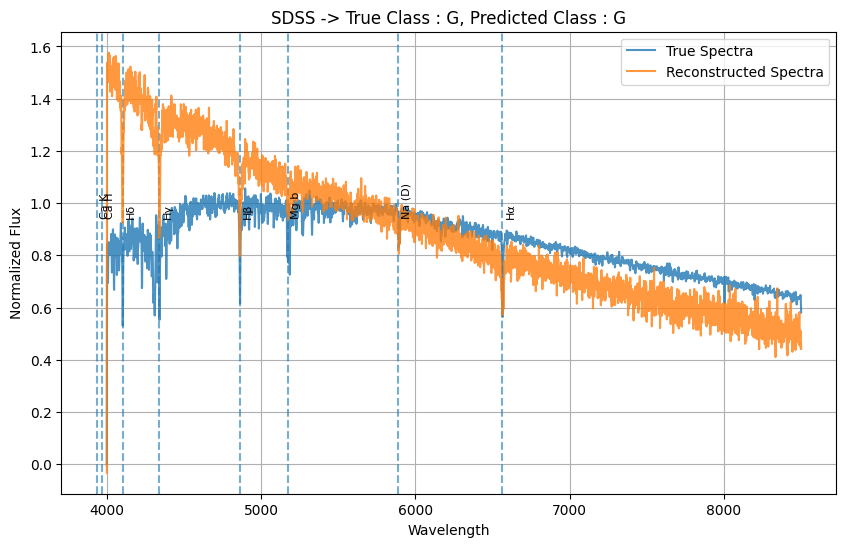

In [7]:

random_star_index_sdss = random.randint(0, 3241)
sdss_star_flux = sdss_flux_best_seed[random_star_index_sdss]
sdss_recon_flux = sdss_recon_best_seed[random_star_index_sdss]

sdss_true_cls = ""
sdss_pred_cls = ""
spectral_class_dict = {"O": 0, "B": 1, "A": 2, "F": 3, "G": 4, "K": 5, "M": 6}
for i in spectral_class_dict:
    if spectral_class_dict[i] == sdss_true_class[random_star_index_sdss]:
        sdss_true_cls = i
    if spectral_class_dict[i] == sdss_pred_class[random_star_index_sdss]:
        sdss_pred_cls = i

spectral_lines = {
    "Hα": 6563,
    "Hβ": 4861,
    "Hγ": 4341,
    "Hδ": 4102,
    "Na (D)": 5890,
    "Ca K": 3934,
    "Ca H": 3969,
    "Mg b": 5175
}

plt.figure(figsize=(10,6))

# Plot vertical lines
for label, wl in spectral_lines.items():
    plt.axvline(x=wl, linestyle='--', alpha=0.6)
    plt.text(wl + 20, max(sdss_star_flux)*0.9, label, rotation=90, fontsize=8)

plt.title(f"SDSS -> True Class : {sdss_true_cls}, Predicted Class : {sdss_pred_cls}")
plt.grid()
plt.plot(wavelength_grid, sdss_star_flux, label = "True Spectra", alpha = 0.8)
plt.plot(wavelength_grid, sdss_recon_flux, label = "Reconstructed Spectra", alpha = 0.8)
plt.xlabel("Wavelength")
plt.ylabel("Normalized Flux")
plt.legend()
plt.show()

LAMOST Reconstruction

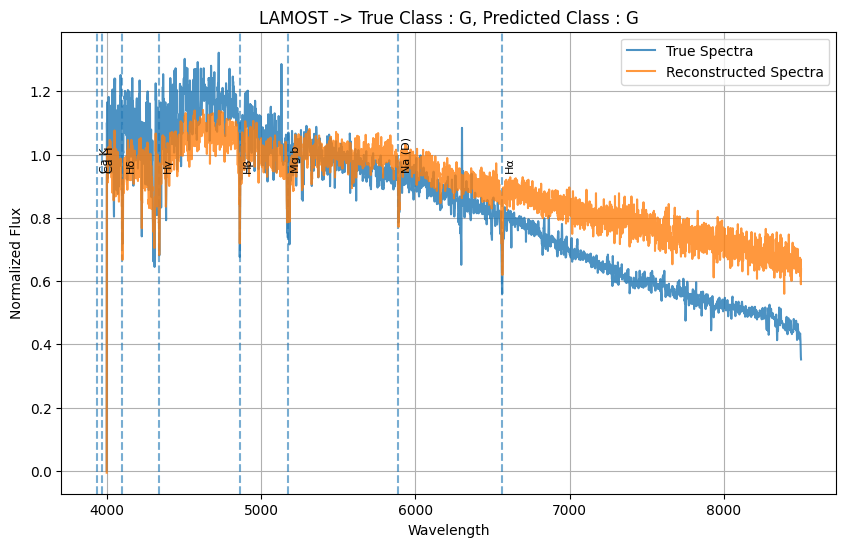

In [8]:
random_star_index_lamost = random.randint(0, 19799)
lamost_star_flux = lamost_flux_best_seed[random_star_index_lamost]
lamost_star_recon = lamost_recon_best_seed[random_star_index_lamost]

lamost_true_cls = ""
lamost_pred_cls = ""
spectral_class_dict = {"O": 0, "B": 1, "A": 2, "F": 3, "G": 4, "K": 5, "M": 6}
for i in spectral_class_dict:
    if spectral_class_dict[i] == lamost_true_class[random_star_index_sdss]:
        lamost_true_cls = i
    if spectral_class_dict[i] == lamost_pred_class[random_star_index_sdss]:
        lamost_pred_cls = i

spectral_lines = {
    "Hα": 6563,
    "Hβ": 4861,
    "Hγ": 4341,
    "Hδ": 4102,
    "Na (D)": 5890,
    "Ca K": 3934,
    "Ca H": 3969,
    "Mg b": 5175
}

plt.figure(figsize=(10,6))

# Plot vertical lines
for label, wl in spectral_lines.items():
    plt.axvline(x=wl, linestyle='--', alpha=0.6)
    plt.text(wl + 20, max(sdss_star_flux)*0.9, label, rotation=90, fontsize=8)

plt.title(f"LAMOST -> True Class : {lamost_true_cls}, Predicted Class : {lamost_pred_cls}")
plt.grid()
plt.plot(wavelength_grid, lamost_star_flux, label = "True Spectra", alpha = 0.8)
plt.plot(wavelength_grid, lamost_star_recon, label = "Reconstructed Spectra", alpha = 0.8)
plt.xlabel("Wavelength")
plt.ylabel("Normalized Flux")
plt.legend()
plt.show()

#### MAE Per Wavelength Pixel

In [9]:
spectral_lines = {
    "Hα": 6563, "Hβ": 4861, "Hγ": 4341, "Hδ": 4102,
    "Na D": 5890, "Mg b": 5175
}

# accumulate per-wavelength errors across seeds
sdss_per_pixel_all   = []
lamost_per_pixel_all = []

for seed in seeds:

    seed_dir = os.path.join(experiments_dir, f"experiment_{seed}")
    
    try:
        sdss_flux = np.load(os.path.join(seed_dir, "sdss_flux.npy"))
        sdss_recon = np.load(os.path.join(seed_dir, "sdss_x_hat.npy"))

        lamost_flux = np.load(os.path.join(seed_dir, "lamost_flux.npy"))
        lamost_recon = np.load(os.path.join(seed_dir, "lamost_x_hat.npy"))

        sdss_per_pixel = np.mean(np.abs(sdss_flux - sdss_recon), axis = 0)
        lamost_per_pixel = np.mean(np.abs(lamost_flux - lamost_recon), axis = 0)

        sdss_per_pixel_all.append(sdss_per_pixel)
        lamost_per_pixel_all.append(lamost_per_pixel)

        print(f"Seed {seed} done")

    except FileNotFoundError as e:
        print(f"Seed {seed} missing: {e}")

# stack into arrays — shape (n_seeds, 3800)
sdss_per_pixel_all   = np.array(sdss_per_pixel_all)
lamost_per_pixel_all = np.array(lamost_per_pixel_all)

# mean and std across seeds — shape (3800,)
sdss_mean   = sdss_per_pixel_all.mean(axis=0)
sdss_std    = sdss_per_pixel_all.std(axis=0)
lamost_mean = lamost_per_pixel_all.mean(axis=0)
lamost_std  = lamost_per_pixel_all.std(axis=0)

Seed 1 done
Seed 7 done
Seed 42 done
Seed 85 done
Seed 123 done
Seed 156 done
Seed 234 done
Seed 301 done
Seed 412 done
Seed 500 done
Seed 617 done
Seed 724 done
Seed 836 done
Seed 901 done
Seed 999 done
Seed 1042 done


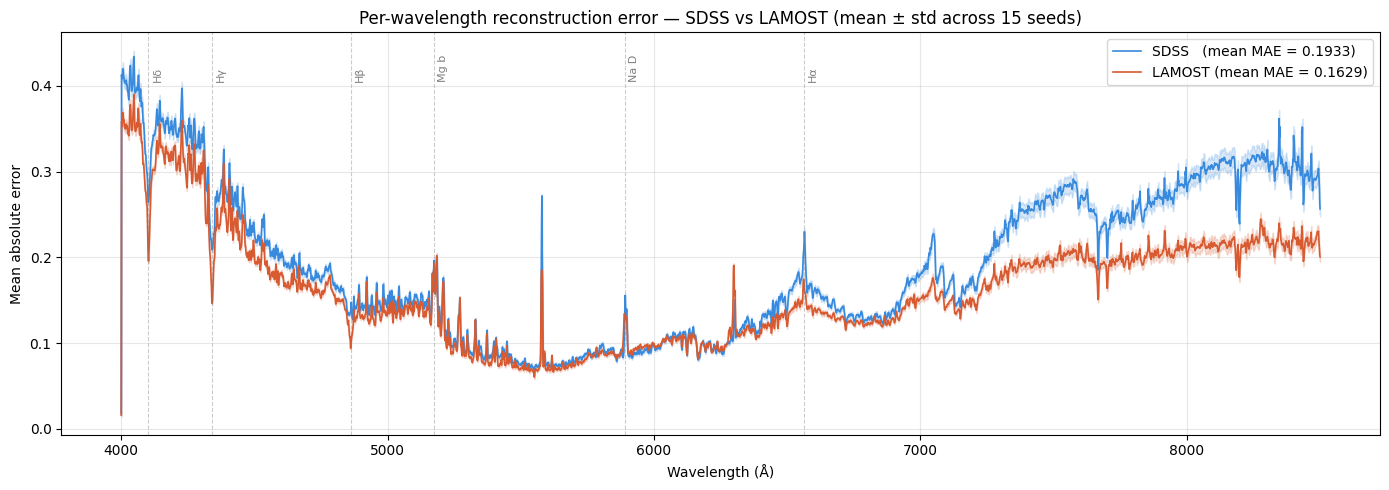

In [10]:
fig, ax = plt.subplots(figsize=(14, 5))

# mean lines
ax.plot(wavelength_grid, sdss_mean,
        label=f"SDSS   (mean MAE = {sdss_mean.mean():.4f})",
        color="#378ADD", linewidth=1.2)
ax.plot(wavelength_grid, lamost_mean,
        label=f"LAMOST (mean MAE = {lamost_mean.mean():.4f})",
        color="#D85A30", linewidth=1.2)

# uncertainty bands across seeds
ax.fill_between(wavelength_grid,
                sdss_mean - sdss_std,
                sdss_mean + sdss_std,
                alpha=0.2, color="#378ADD")
ax.fill_between(wavelength_grid,
                lamost_mean - lamost_std,
                lamost_mean + lamost_std,
                alpha=0.2, color="#D85A30")

# spectral line markers
for label, wl in spectral_lines.items():
    if 4000 <= wl <= 8500:
        ax.axvline(x=wl, linestyle="--", alpha=0.4, color="gray", linewidth=0.8)
        ax.text(wl + 15, ax.get_ylim()[1] * 0.88,
                label, rotation=90, fontsize=8, color="gray")

ax.set_xlabel("Wavelength (Å)")
ax.set_ylabel("Mean absolute error")
ax.set_title("Per-wavelength reconstruction error — SDSS vs LAMOST (mean ± std across 15 seeds)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(experiments_dir, "per_wavelength_error.png"), dpi=150)
plt.show()

### H2 

In [16]:
param_names = ["T_eff", "log_g", "Fe_H"]

results = {
    param: {
        "sdss_mean_rho"  : [],
        "lamost_mean_rho": [],
        "retention_pct"  : []
    }
    for param in param_names
}
for seed in tqdm(seeds):
    seed_dir = os.path.join(experiments_dir, f"experiment_{seed}")

    try:
        sdss_latent_mu = np.load(os.path.join(seed_dir, "sdss_latent_mu.npy"))
        sdss_true_param = np.load(os.path.join(seed_dir, "sdss_true_reg.npy"))

        lamost_latent_mu = np.load(os.path.join(seed_dir, "lamost_latent_mu.npy"))
        lamost_true_param = np.load(os.path.join(seed_dir, "lamost_true_reg.npy"))
        
        sdss_params = {
            "T_eff" : sdss_true_param[:, 0] * reg_sigma[0] + reg_mu[0],
            "log_g" : sdss_true_param[:, 1] * reg_sigma[1] + reg_mu[1],
            "Fe_H" : sdss_true_param[:, 2] * reg_sigma[2] + reg_mu[2]
        }

        lamost_params = {
            "T_eff" : lamost_true_param[:, 0] * reg_sigma[0] + reg_mu[0],
            "log_g" : lamost_true_param[:, 1] * reg_sigma[1] + reg_mu[1],
            "Fe_H" : lamost_true_param[:, 2] * reg_sigma[2] + reg_mu[2]
        }

        for param_name in param_names:
            sdss_rhos, lamost_rhos = [], []
    
            for dim in range(sdss_latent_mu.shape[1]):
                rho_sdss, _  = spearmanr(sdss_latent_mu[:, dim], sdss_params[param_name])
                rho_lamost, _ = spearmanr(lamost_latent_mu[:, dim], lamost_params[param_name])

                sdss_rhos.append(abs(rho_sdss))
                lamost_rhos.append(abs(rho_lamost))

            sdss_rhos   = np.array(sdss_rhos)
            lamost_rhos = np.array(lamost_rhos)

            sdss_mean = float(sdss_rhos.mean())
            lamost_mean = float(lamost_rhos.mean())

            retention   = (lamost_mean / sdss_mean) * 100 if sdss_mean > 0 else 0.0


            results[param_name]["sdss_mean_rho"].append(sdss_mean)
            results[param_name]["lamost_mean_rho"].append(lamost_mean)
            results[param_name]["retention_pct"].append(retention)
            
        

    except FileNotFoundError as e:
        print(f"Seed {seed} missing: {e}")
        

100%|██████████| 16/16 [00:27<00:00,  1.70s/it]


#### Summary of Spearman correlation test

In [19]:
summary = {}

for param in param_names:
    sdss_mean = np.mean(results[param]["sdss_mean_rho"])
    sdss_std = np.std(results[param]["sdss_mean_rho"])
    lamost_mean = np.mean(results[param]["lamost_mean_rho"])
    lamost_std  = np.std(results[param]["lamost_mean_rho"])
    ret_mean    = np.mean(results[param]["retention_pct"])
    ret_std     = np.std(results[param]["retention_pct"])

    print(f"{param:<10} "
          f"{sdss_mean:.4f} ± {sdss_std:.4f}   "
          f"{lamost_mean:.4f} ± {lamost_std:.4f}   "
          f"{ret_mean:.1f} ± {ret_std:.1f}%")

    summary[param] = {
        "sdss_mean_rho_mean"  : float(sdss_mean),
        "sdss_mean_rho_std"   : float(sdss_std),
        "lamost_mean_rho_mean": float(lamost_mean),
        "lamost_mean_rho_std" : float(lamost_std),
        "retention_mean_pct"  : float(ret_mean),
        "retention_std_pct"   : float(ret_std)
    }

with open(os.path.join(experiments_dir, "h2_results.json"), "w") as f:
    json.dump({"per_seed": results, "summary": summary}, f, indent=2)

print("\nSaved to h2_results.json")

T_eff      0.2544 ± 0.0096   0.4236 ± 0.0197   166.9 ± 11.1%
log_g      0.2151 ± 0.0095   0.2086 ± 0.0093   97.2 ± 6.6%
Fe_H       0.1416 ± 0.0073   0.1531 ± 0.0114   108.6 ± 11.8%

Saved to h2_results.json


Correlation doesn't degrade but infact gets better

### Spearman visualization

Mean Rho for each parameter comparing SDSS and LAMOST

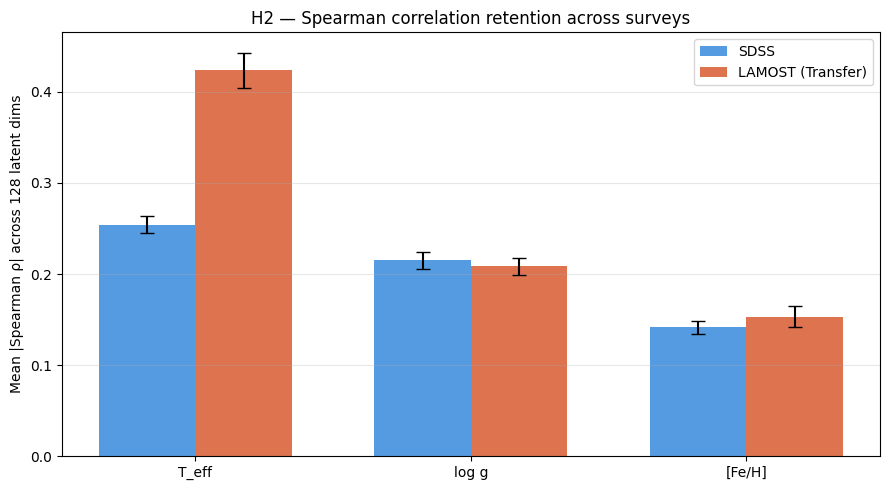

In [21]:
import matplotlib.pyplot as plt
import numpy as np

params      = ["T_eff", "log g", "[Fe/H]"]
sdss_rhos   = [0.2544, 0.2151, 0.1416]
sdss_stds   = [0.0096, 0.0095, 0.0073]
lamost_rhos = [0.4236, 0.2086, 0.1531]
lamost_stds = [0.0197, 0.0093, 0.0114]

x     = np.arange(len(params))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(x - width/2, sdss_rhos, width,
       yerr=sdss_stds, capsize=5,
       label="SDSS", color="#378ADD", alpha=0.85)
ax.bar(x + width/2, lamost_rhos, width,
       yerr=lamost_stds, capsize=5,
       label="LAMOST (Transfer)", color="#D85A30", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(params)
ax.set_ylabel("Mean |Spearman ρ| across 128 latent dims")
ax.set_title("H2 — Spearman correlation retention across surveys")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("h2_retention_bar.png", dpi=150)
plt.show()

#### Latent Space Visualizations

Fitting UMAP on SDSS...


/home/arbiter/projects/Survey-invariant-generalization/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Fitting UMAP on LAMOST...


/home/arbiter/projects/Survey-invariant-generalization/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


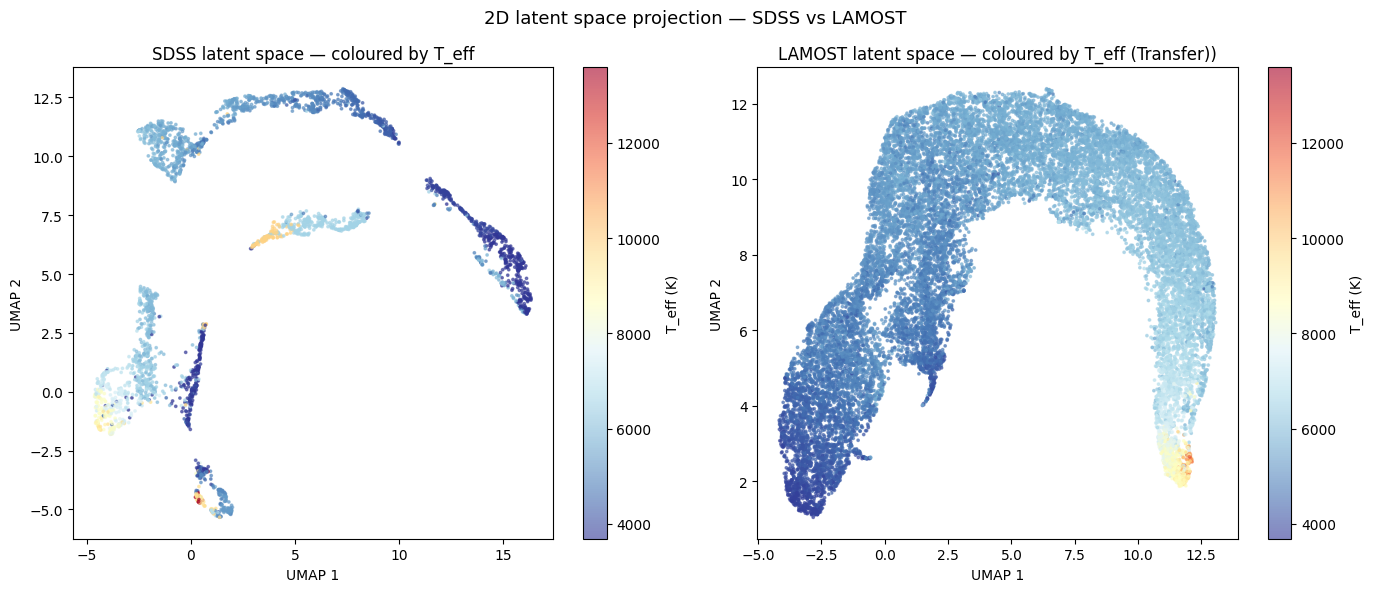

Saved umap_2d_teff.png


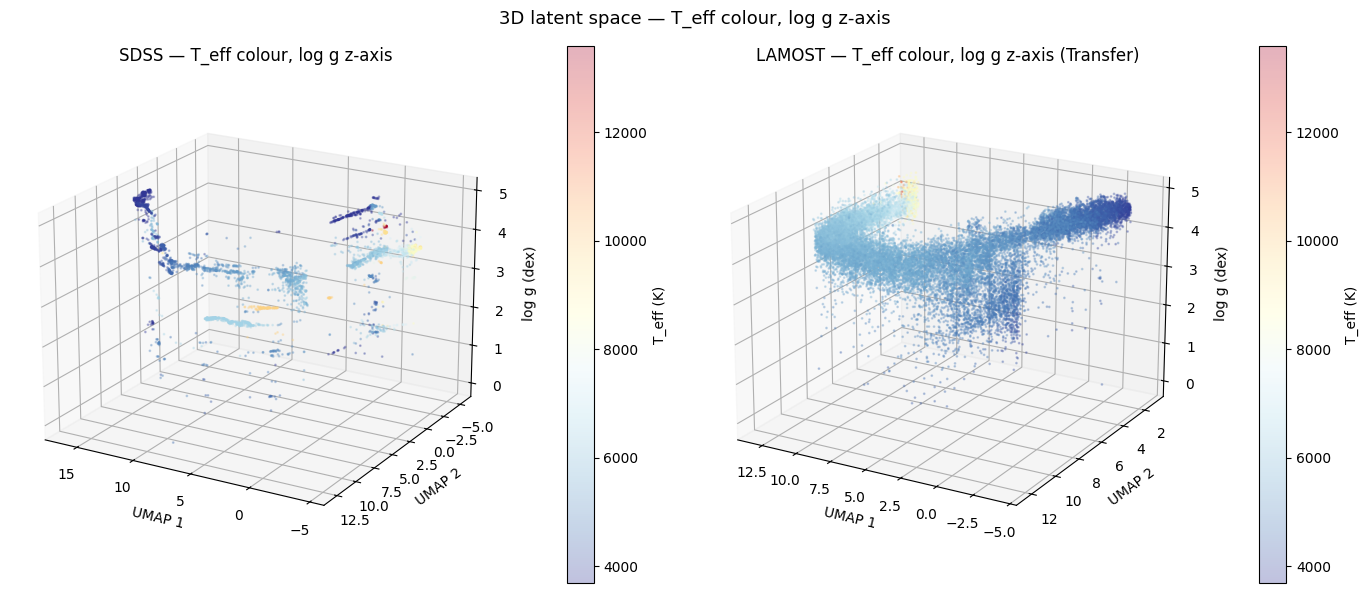

Saved umap_3d_logg.png


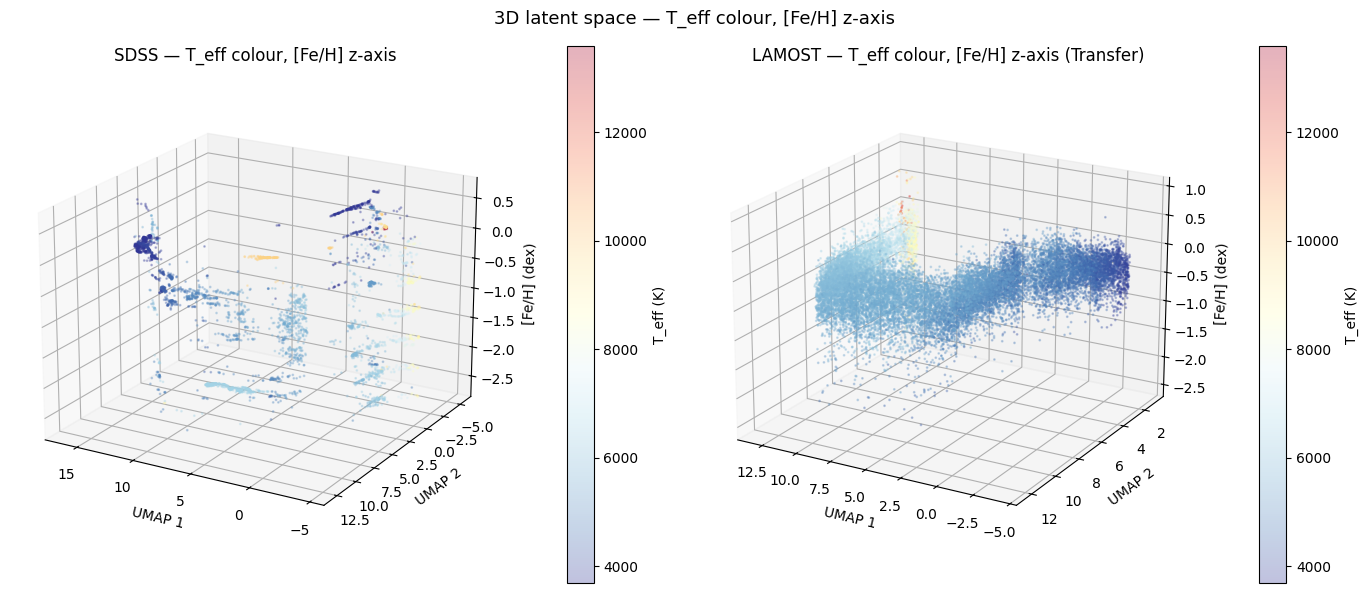

Saved umap_3d_feh.png


In [25]:
# used CLAUDE AI for this 

import numpy as np
import matplotlib.pyplot as plt
import umap
import os

experiments_dir = "/home/arbiter/projects/Survey-invariant-generalization/experiments/experiments_data"

reg_mu    = np.load("/home/arbiter/projects/Survey-invariant-generalization/src/models/reg_mu.npy")
reg_sigma = np.load("/home/arbiter/projects/Survey-invariant-generalization/src/models/reg_sigma.npy")

# use a single seed for visualization — seed 123 (best model)
seed_dir = os.path.join(experiments_dir, "experiment_123")

sdss_mu     = np.load(os.path.join(seed_dir, "sdss_latent_mu.npy"))
lamost_mu   = np.load(os.path.join(seed_dir, "lamost_latent_mu.npy"))
sdss_true   = np.load(os.path.join(seed_dir, "sdss_true_reg.npy"))
lamost_true = np.load(os.path.join(seed_dir, "lamost_true_reg.npy"))

# denormalize all parameters
sdss_teff  = sdss_true[:, 0]   * reg_sigma[0] + reg_mu[0]
sdss_logg  = sdss_true[:, 1]   * reg_sigma[1] + reg_mu[1]
sdss_feh   = sdss_true[:, 2]   * reg_sigma[2] + reg_mu[2]

lamost_teff = lamost_true[:, 0] * reg_sigma[0] + reg_mu[0]
lamost_logg = lamost_true[:, 1] * reg_sigma[1] + reg_mu[1]
lamost_feh  = lamost_true[:, 2] * reg_sigma[2] + reg_mu[2]

# UMAP reduction
# fit on SDSS, transform LAMOST separately
# use same hyperparameters for both so projections are comparable
print("Fitting UMAP on SDSS...")
reducer_sdss = umap.UMAP(
    n_components  = 2,
    n_neighbors   = 30,
    min_dist      = 0.1,
    random_state  = 42
)
sdss_2d = reducer_sdss.fit_transform(sdss_mu)

print("Fitting UMAP on LAMOST...")
reducer_lamost = umap.UMAP(
    n_components  = 2,
    n_neighbors   = 30,
    min_dist      = 0.1,
    random_state  = 42
)
lamost_2d = reducer_lamost.fit_transform(lamost_mu)

# shared T_eff color scale across both surveys
teff_vmin = min(sdss_teff.min(), lamost_teff.min())
teff_vmax = max(sdss_teff.max(), lamost_teff.max())


# PLOT 1 — 2D UMAP coloured by T_eff

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(
    sdss_2d[:, 0], sdss_2d[:, 1],
    c     = sdss_teff,
    cmap  = "RdYlBu_r",
    s     = 3,
    alpha = 0.6,
    vmin  = teff_vmin,
    vmax  = teff_vmax
)
plt.colorbar(sc1, ax=axes[0], label="T_eff (K)")
axes[0].set_title("SDSS latent space — coloured by T_eff")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")

sc2 = axes[1].scatter(
    lamost_2d[:, 0], lamost_2d[:, 1],
    c     = lamost_teff,
    cmap  = "RdYlBu_r",
    s     = 3,
    alpha = 0.6,
    vmin  = teff_vmin,
    vmax  = teff_vmax
)
plt.colorbar(sc2, ax=axes[1], label="T_eff (K)")
axes[1].set_title("LAMOST latent space — coloured by T_eff (Transfer))")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")

plt.suptitle("2D latent space projection — SDSS vs LAMOST", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(experiments_dir, "umap_2d_teff.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved umap_2d_teff.png")

# PLOT 2a — 3D UMAP with log g as z axis

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection="3d")
ax2 = fig.add_subplot(122, projection="3d")

sc1 = ax1.scatter(
    sdss_2d[:, 0], sdss_2d[:, 1], sdss_logg,
    c          = sdss_teff,
    cmap       = "RdYlBu_r",
    s          = 1,
    alpha      = 0.3,
    vmin       = teff_vmin,
    vmax       = teff_vmax,
    depthshade = False,
    rasterized = True
)
ax1.view_init(elev=20, azim=120)
ax1.set_title("SDSS — T_eff colour, log g z-axis")
ax1.set_xlabel("UMAP 1")
ax1.set_ylabel("UMAP 2")
ax1.set_zlabel("log g (dex)")
plt.colorbar(sc1, ax=ax1, pad=0.1, label="T_eff (K)")

sc2 = ax2.scatter(
    lamost_2d[:, 0], lamost_2d[:, 1], lamost_logg,
    c          = lamost_teff,
    cmap       = "RdYlBu_r",
    s          = 1,
    alpha      = 0.3,
    vmin       = teff_vmin,
    vmax       = teff_vmax,
    depthshade = False,
    rasterized = True
)
ax2.view_init(elev=20, azim=120)
ax2.set_title("LAMOST — T_eff colour, log g z-axis (Transfer)")
ax2.set_xlabel("UMAP 1")
ax2.set_ylabel("UMAP 2")
ax2.set_zlabel("log g (dex)")
plt.colorbar(sc2, ax=ax2, pad=0.1, label="T_eff (K)")

plt.suptitle("3D latent space — T_eff colour, log g z-axis", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(experiments_dir, "umap_3d_logg.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved umap_3d_logg.png")


# PLOT 2b — 3D UMAP with metallicity as z axis

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection="3d")
ax2 = fig.add_subplot(122, projection="3d")

sc1 = ax1.scatter(
    sdss_2d[:, 0], sdss_2d[:, 1], sdss_feh,
    c          = sdss_teff,
    cmap       = "RdYlBu_r",
    s          = 1,
    alpha      = 0.3,
    vmin       = teff_vmin,
    vmax       = teff_vmax,
    depthshade = False,
    rasterized = True
)
ax1.view_init(elev=20, azim=120)
ax1.set_title("SDSS — T_eff colour, [Fe/H] z-axis")
ax1.set_xlabel("UMAP 1")
ax1.set_ylabel("UMAP 2")
ax1.set_zlabel("[Fe/H] (dex)")
plt.colorbar(sc1, ax=ax1, pad=0.1, label="T_eff (K)")

sc2 = ax2.scatter(
    lamost_2d[:, 0], lamost_2d[:, 1], lamost_feh,
    c          = lamost_teff,
    cmap       = "RdYlBu_r",
    s          = 1,
    alpha      = 0.3,
    vmin       = teff_vmin,
    vmax       = teff_vmax,
    depthshade = False,
    rasterized = True
)
ax2.view_init(elev=20, azim=120)
ax2.set_title("LAMOST — T_eff colour, [Fe/H] z-axis (Transfer)")
ax2.set_xlabel("UMAP 1")
ax2.set_ylabel("UMAP 2")
ax2.set_zlabel("[Fe/H] (dex)")
plt.colorbar(sc2, ax=ax2, pad=0.1, label="T_eff (K)")

plt.suptitle("3D latent space — T_eff colour, [Fe/H] z-axis", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(experiments_dir, "umap_3d_feh.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved umap_3d_feh.png")

## H2 - Baselines model comparison